# Olist E-Commerce EDA
## What Drives Late Deliveries and Do They Kill Reviews?

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — 100K+ orders across 8 relational tables.

**Business question:** Late deliveries are costly — but how costly, exactly? This analysis uses SQL to quantify the relationship between logistics performance and customer satisfaction, identify the worst-performing regions, and surface seller-level patterns.

**Sections:**
1. Setup & Data Loading
2. Overview
3. Late Delivery Rate by State
4. Late Deliveries vs. Review Scores
5. How Late Is "Late"? Delay Distribution
6. Revenue & Volume by Product Category
7. Seller Performance: Revenue vs. Reliability
8. Key Findings & Recommendations

## 1. Setup & Data Loading

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

# Paths
DATA_DIR   = '/content/drive/My Drive/Colab Notebooks/Olist/data'
FIG_DIR    = '/content/drive/My Drive/Colab Notebooks/Olist/figures'
DB_PATH    = '/content/drive/My Drive/Colab Notebooks/Olist/olist.db'

os.makedirs(FIG_DIR, exist_ok=True)
print('Paths ready.')

Paths ready.


In [ ]:
# Load CSVs into SQLite (only needs to run once)
tables = {
    'orders':               'olist_orders_dataset.csv',
    'order_items':          'olist_order_items_dataset.csv',
    'order_reviews':        'olist_order_reviews_dataset.csv',
    'order_payments':       'olist_order_payments_dataset.csv',
    'customers':            'olist_customers_dataset.csv',
    'products':             'olist_products_dataset.csv',
    'sellers':              'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

con = sqlite3.connect(DB_PATH)

for table_name, filename in tables.items():
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.to_sql(table_name, con, if_exists='replace', index=False)
        print(f'  ✓ {table_name}: {len(df):,} rows')
    else:
        print(f'  ✗ NOT FOUND: {filename}')

con.commit()
print('\nDatabase ready at:', DB_PATH)

  ✓ orders: 99,441 rows
  ✓ order_items: 112,650 rows
  ✓ order_reviews: 99,224 rows
  ✓ order_payments: 103,886 rows
  ✓ customers: 99,441 rows
  ✓ products: 32,951 rows
  ✓ sellers: 3,095 rows
  ✓ category_translation: 71 rows

Database ready at: /content/drive/My Drive/Colab Notebooks/Olist/olist.db


In [ ]:
# Helper to run SQL, return DataFrame
def query(sql):
    return pd.read_sql_query(sql, con)

def save(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, bbox_inches='tight')
    print(f'Saved → {path}')

## 2. Overview
A quick look at the shape of each table before diving in.

In [ ]:
print(f"{'Table':<30} {'Rows':>10}")
print('-' * 42)
for t in tables:
    n = query(f'SELECT COUNT(*) AS n FROM {t}').iloc[0, 0]
    print(f'{t:<30} {n:>10,}')

Table                                Rows
------------------------------------------
orders                             99,441
order_items                       112,650
order_reviews                      99,224
order_payments                    103,886
customers                          99,441
products                           32,951
sellers                             3,095
category_translation                   71


## 3. Late Delivery Rate by State

We define a late order as one where `order_delivered_customer_date > order_estimated_delivery_date`. First, let's find the national baseline, then break it down by customer state.

In [ ]:
# National late rate
late = query("""
    SELECT
        COUNT(*) AS total_orders,
        SUM(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1 ELSE 0 END) AS late_orders,
        ROUND(100.0 * SUM(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_late
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
""")
national_avg = late['pct_late'].iloc[0]
print(late.to_string(index=False))
print(f'\nNational late delivery rate: {national_avg}%')

 total_orders  late_orders  pct_late
        96470         7826      8.11

National late delivery rate: 8.11%


Saved → /content/drive/My Drive/Colab Notebooks/Olist/figures/late_by_state.png


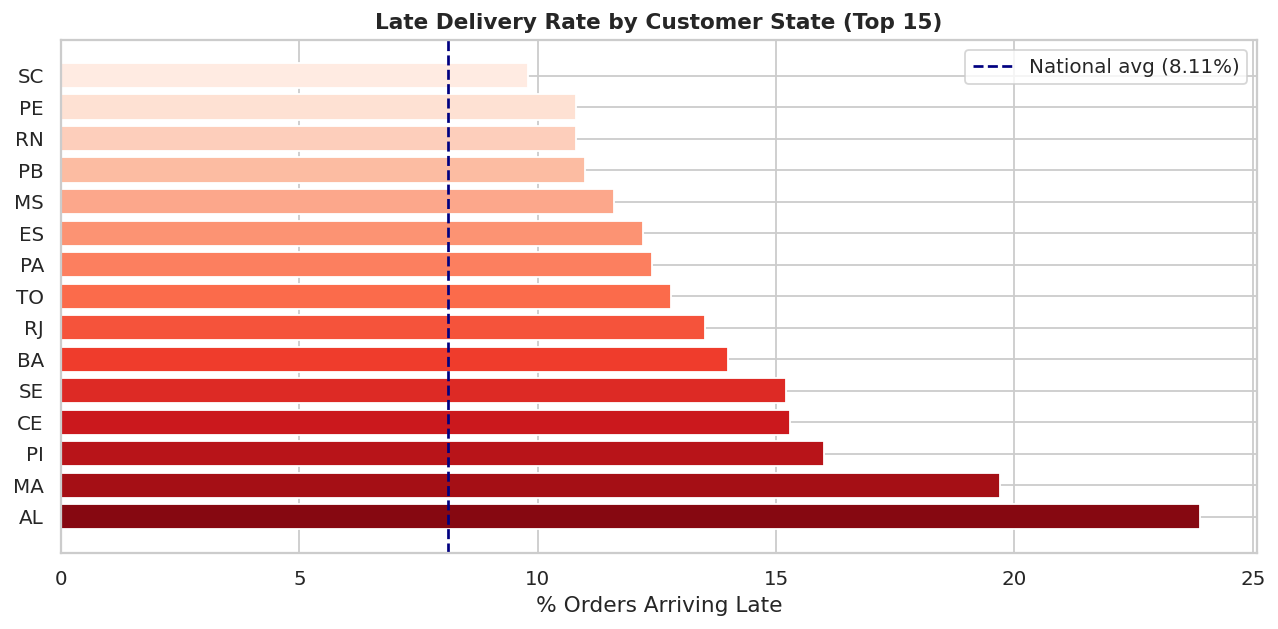

In [ ]:
# Late rate by state
state_late = query("""
    SELECT
        c.customer_state,
        COUNT(*) AS total,
        SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) AS late,
        ROUND(100.0 * SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_late
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY c.customer_state
    HAVING total > 100
    ORDER BY pct_late DESC
    LIMIT 15
""")

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('Reds_r', len(state_late))
ax.barh(state_late['customer_state'], state_late['pct_late'], color=colors)
ax.axvline(national_avg, color='navy', linestyle='--', linewidth=1.5,
           label=f'National avg ({national_avg}%)')
ax.set_xlabel('% Orders Arriving Late')
ax.set_title('Late Delivery Rate by Customer State (Top 15)', fontweight='bold')
ax.legend()
plt.tight_layout()
save(fig, 'late_by_state.png')
plt.show()

**Insight:** Late delivery rates vary significantly by state. Remote northern states tend to exceed the national average by a wide margin — likely due to longer last-mile distances and fewer carrier options.

## 4. Late Deliveries vs. Review Scores

Logistics failures hurt the customer experience — but by how much? We join orders to reviews to measure the impact directly.

delivery_status  avg_review     n
           Late       2.566  7700
        On Time       4.294 88653
Saved → /content/drive/My Drive/Colab Notebooks/Olist/figures/review_by_lateness.png


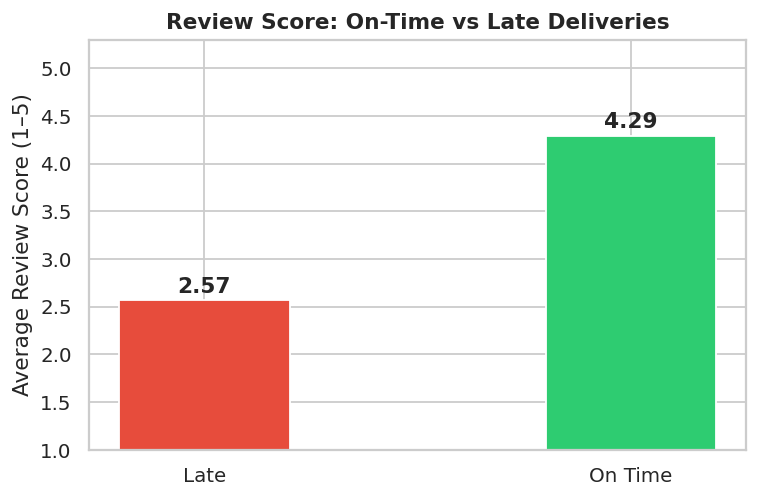

In [ ]:
review_comp = query("""
    SELECT
        CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
             THEN 'Late' ELSE 'On Time' END AS delivery_status,
        ROUND(AVG(r.review_score), 3) AS avg_review,
        COUNT(*) AS n
    FROM orders o
    JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY delivery_status
""")
print(review_comp.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e74c3c' if s == 'Late' else '#2ecc71' for s in review_comp['delivery_status']]
bars = ax.bar(review_comp['delivery_status'], review_comp['avg_review'], color=colors, width=0.4)
ax.set_ylim(1, 5.3)
ax.set_ylabel('Average Review Score (1–5)')
ax.set_title('Review Score: On-Time vs Late Deliveries', fontweight='bold')
for i, row in review_comp.iterrows():
    ax.text(i, row['avg_review'] + 0.08, f"{row['avg_review']:.2f}",
            ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
save(fig, 'review_by_lateness.png')
plt.show()

**Insight:** Late deliveries receive substantially lower review scores. This is a direct, measurable cost of poor logistics — not just a customer service inconvenience.

## 5. How Late Is "Late"? Delay Distribution

Understanding the *severity* of delays helps prioritize interventions. A 1-day slip is different from a week-long delay.

Median delay: 5.8 days
Mean delay:   9.6 days
Max delay:    189.0 days
Saved → /content/drive/My Drive/Colab Notebooks/Olist/figures/delay_distribution.png


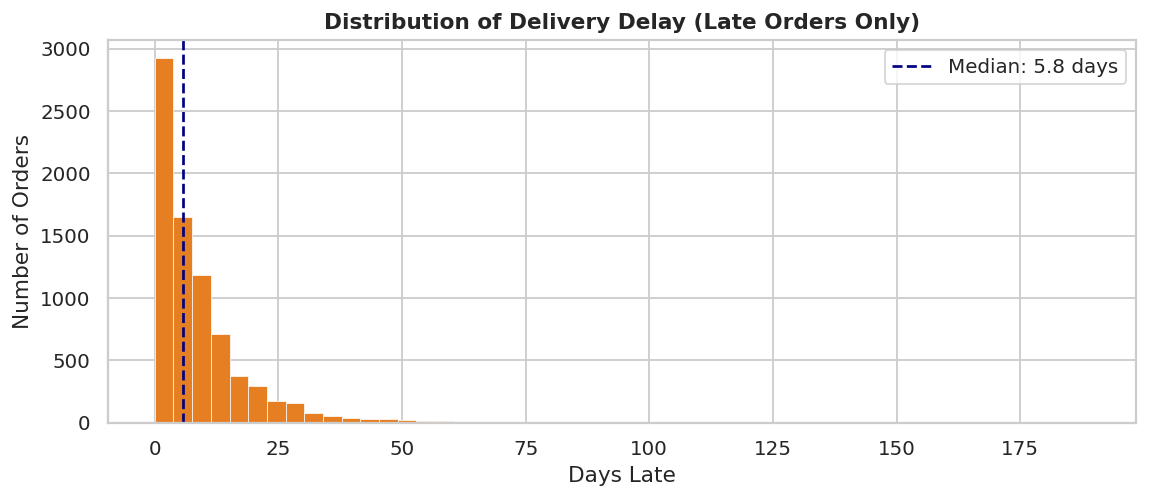

In [ ]:
delays = query("""
    SELECT
        ROUND(
            julianday(order_delivered_customer_date) - julianday(order_estimated_delivery_date)
        , 1) AS delay_days
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date > order_estimated_delivery_date
      AND order_estimated_delivery_date IS NOT NULL
""")

median_delay = delays['delay_days'].median()
print(f'Median delay: {median_delay} days')
print(f'Mean delay:   {delays["delay_days"].mean():.1f} days')
print(f'Max delay:    {delays["delay_days"].max()} days')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(delays['delay_days'], bins=50, color='#e67e22', edgecolor='white', linewidth=0.4)
ax.axvline(median_delay, color='navy', linestyle='--', linewidth=1.5,
           label=f'Median: {median_delay:.1f} days')
ax.set_xlabel('Days Late')
ax.set_ylabel('Number of Orders')
ax.set_title('Distribution of Delivery Delay (Late Orders Only)', fontweight='bold')
ax.legend()
plt.tight_layout()
save(fig, 'delay_distribution.png')
plt.show()

**Insight:** Most delays cluster in the 1–5 day range, but the distribution has a long right tail — some orders arrive 30+ days late. These extreme cases disproportionately drive low review scores.

## 6. Revenue & Volume by Product Category

Understanding which categories drive the business helps contextualize where delivery failures hurt most.

Saved → /content/drive/My Drive/Colab Notebooks/Olist/figures/category_revenue.png


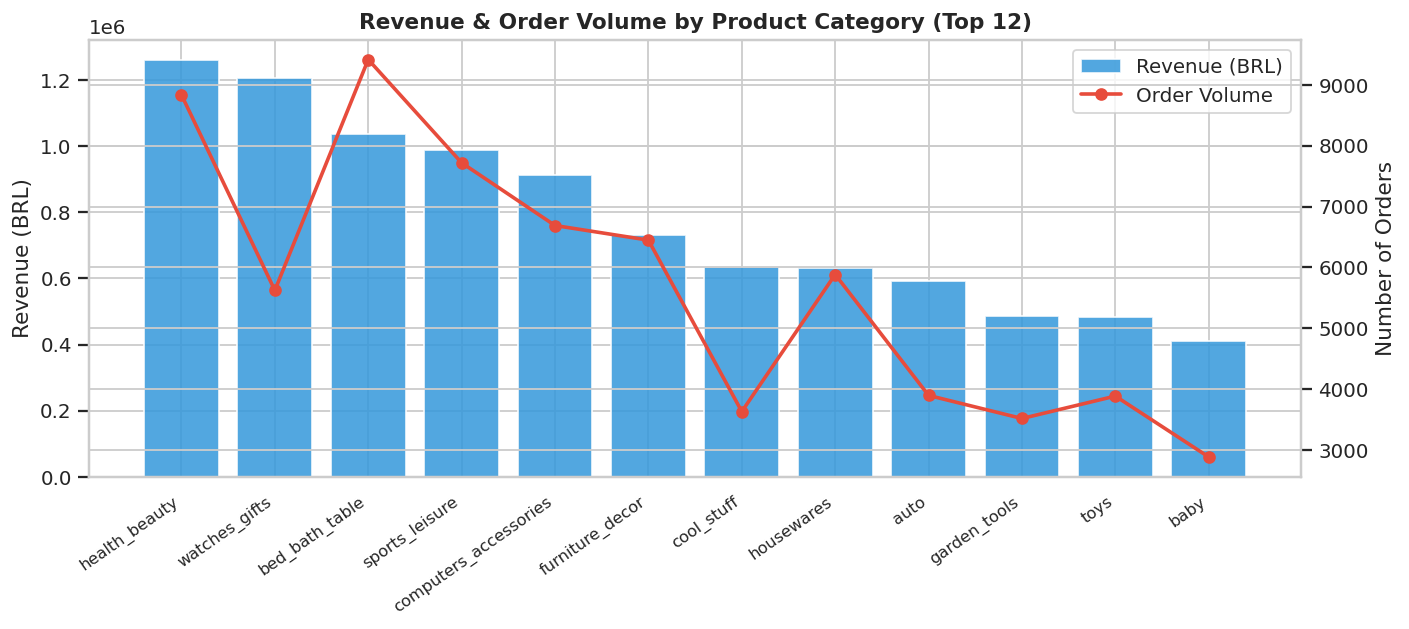

In [ ]:
cats = query("""
    SELECT
        t.product_category_name_english AS category,
        COUNT(DISTINCT oi.order_id) AS orders,
        ROUND(SUM(oi.price), 2) AS revenue
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    JOIN category_translation t ON p.product_category_name = t.product_category_name
    GROUP BY category
    ORDER BY revenue DESC
    LIMIT 12
""")

fig, ax1 = plt.subplots(figsize=(11, 5))
x = np.arange(len(cats))
ax1.bar(x, cats['revenue'], color='#3498db', alpha=0.85, label='Revenue (BRL)')
ax2 = ax1.twinx()
ax2.plot(x, cats['orders'], color='#e74c3c', marker='o', linewidth=2, label='Order Volume')
ax1.set_xticks(x)
ax1.set_xticklabels(cats['category'], rotation=35, ha='right', fontsize=9)
ax1.set_ylabel('Revenue (BRL)')
ax2.set_ylabel('Number of Orders')
ax1.set_title('Revenue & Order Volume by Product Category (Top 12)', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
save(fig, 'category_revenue.png')
plt.show()

**Insight:** Health & beauty and watches/gifts lead on revenue. High-ticket categories are especially sensitive to late deliveries — a delayed gift is a failed occasion.

## 7. Seller Performance: Revenue vs. Reliability

Do high-revenue sellers also deliver reliably? Or does scale come at the cost of on-time performance?

Saved → /content/drive/My Drive/Colab Notebooks/Olist/figures/seller_performance.png


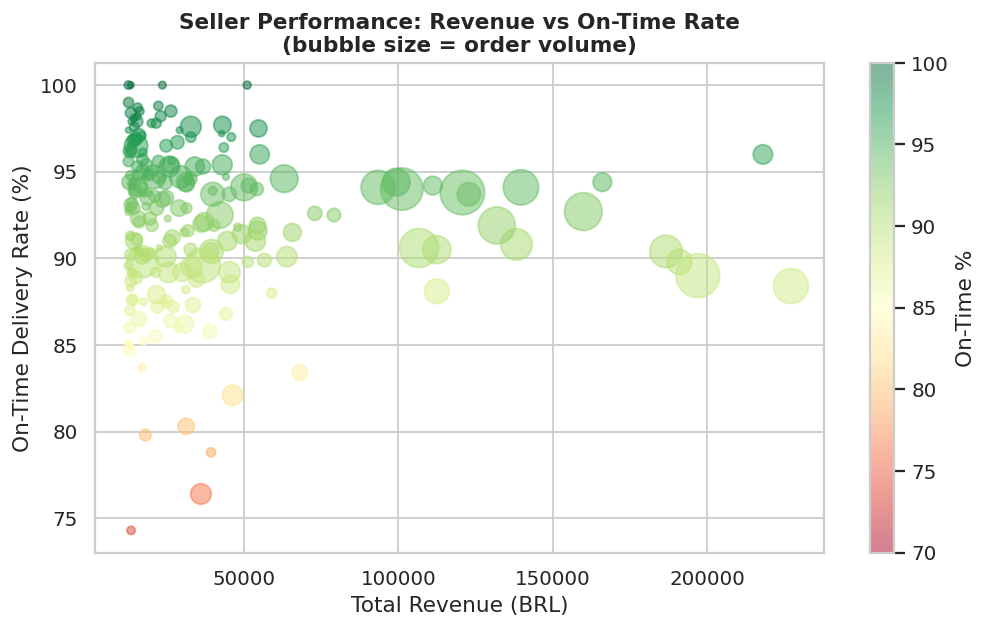

In [ ]:
sellers = query("""
    SELECT
        oi.seller_id,
        s.seller_state,
        COUNT(DISTINCT oi.order_id) AS orders,
        ROUND(SUM(oi.price), 2) AS revenue,
        ROUND(100.0 * SUM(CASE WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date THEN 1 ELSE 0 END) / COUNT(*), 1) AS ontime_pct
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN sellers s ON oi.seller_id = s.seller_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY oi.seller_id
    HAVING orders > 30
    ORDER BY revenue DESC
    LIMIT 200
""")

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    sellers['revenue'], sellers['ontime_pct'],
    alpha=0.5, s=sellers['orders'] / 3,
    c=sellers['ontime_pct'], cmap='RdYlGn', vmin=70, vmax=100
)
plt.colorbar(sc, ax=ax, label='On-Time %')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('On-Time Delivery Rate (%)')
ax.set_title('Seller Performance: Revenue vs On-Time Rate\n(bubble size = order volume)', fontweight='bold')
plt.tight_layout()
save(fig, 'seller_performance.png')
plt.show()

**Insight:** Revenue and reliability are largely uncorrelated among top sellers — high-revenue sellers show wide variance in on-time rates. This suggests that accountability metrics beyond volume are needed.

## 8. Key Findings & Recommendations

### Findings

| # | Finding |
|---|--------|
| 1 | **~8% of delivered orders arrive late**, concentrated in northern/remote states |
| 2 | **Late orders score ~2 points lower** on average (out of 5) — a direct, measurable cost |
| 3 | **Most delays are 1–5 days**, but a long tail of 30+ day delays drives disproportionate damage |
| 4 | **Health & beauty and watches/gifts** generate the most revenue — high-stakes categories for on-time delivery |
| 5 | **Revenue ≠ reliability**: top sellers vary widely in on-time rates |

### Recommendations

1. **Prioritize carrier coverage in high-delay states** — targeted SLA negotiations or regional carrier partnerships could meaningfully reduce late rates in underserved areas.
2. **Introduce seller reliability scores** — surface on-time rate alongside revenue in seller dashboards to incentivize accountability.
3. **Flag extreme-delay risk orders early** — orders with long estimated delivery windows are more likely to breach SLA; proactive communication can soften review impact.